In [1]:
import scanpy as sc
import numpy as np
from scipy.sparse import issparse
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# =============================================================================
# 1. Load annotated (metadata + processed) and raw (counts) AnnData objects
# =============================================================================
# - adata_annot: contains cell-level metadata (Donor, technology, ID, cell type, etc.)
# - adata_raw:   contains raw count matrix used for QC (UMIs, genes, mito, etc.)
#   We will align them by cell barcodes and carry metadata over to the raw counts.
# =============================================================================

adata_annot = sc.read_h5ad('annotated.all_merged.h5ad')
adata_raw   = sc.read_h5ad('raw.all_merged.h5ad')

# -----------------------------------------------------------------------------
# Align observations (cells) by barcode
# -----------------------------------------------------------------------------
# AnnData uses obs_names (cell barcodes) to define row order. We need:
#   - raw counts from adata_raw.X
#   - metadata from adata_annot.obs
# in the *same* cell order to compute QC metrics and then group by metadata.
# If the barcodes don't match in order, reindex adata_raw to annotated's order.
# -----------------------------------------------------------------------------
if not np.array_equal(adata_annot.obs_names, adata_raw.obs_names):
    adata_raw = adata_raw[adata_annot.obs_names].copy()

# -----------------------------------------------------------------------------
# Copy cell metadata from annotated into raw
# -----------------------------------------------------------------------------
# The raw object usually has counts but minimal metadata.
# Here we overwrite adata_raw.obs with a copy of the richer annotation
# (donor, technology, condition, celltype, etc.).
# -----------------------------------------------------------------------------
adata_raw.obs = adata_annot.obs.copy()

# -----------------------------------------------------------------------------
# Copy gene metadata if gene sets are identical
# -----------------------------------------------------------------------------
# We only copy .var if var_names match exactly. If not, we keep the raw .var as-is
# but still use var_names for gene labels.
# -----------------------------------------------------------------------------
if np.array_equal(adata_annot.var_names, adata_raw.var_names):
    adata_raw.var = adata_annot.var.copy()
else:
    print(
        "Warning: the annotated and raw datasets contain different gene sets "
        f"({adata_annot.n_vars} vs {adata_raw.n_vars}).  "
        "Continuing with the raw gene metadata."
    )

# From here on, *adata_raw* is our working object:
#   - adata_raw.X        → raw UMI counts
#   - adata_raw.obs[...] → donor / technology / ID / cell type, etc.


# =============================================================================
# 2. Subset to RBC-depleted samples
# =============================================================================
# We focus on RBC-depleted samples only. The RBC status is encoded in the
# 'ID' field in .obs (strings like '...RBCdepl...'). To be robust, we just
# search for the substring "RBC" in a case-insensitive way.
# =============================================================================

rbc_mask = adata_raw.obs['ID'].astype(str).str.contains('RBC', case=False)
rbc_cells = adata_raw[rbc_mask].copy()

print(f'RBC-depleted cells: {rbc_cells.n_obs}')
print(rbc_cells.obs['technology'].value_counts())


# =============================================================================
# 3. Compute QC metrics from raw counts for RBC-depleted cells
# =============================================================================
# We compute:
#   • total_counts        – total UMI counts per cell (library size)
#   • n_genes_by_counts   – number of detected genes per cell (>0 counts)
#   • mito_fraction       – fraction of counts from mitochondrial genes
#
# These will later be used to reproduce violin plots of QC metrics per
# technology and donor.
# =============================================================================

def axis1_sum(mat):
    """Row-wise sum for dense or sparse matrices."""
    return np.asarray(mat.sum(axis=1)).ravel() if issparse(mat) else mat.sum(axis=1)

def axis1_nnz(mat):
    """Row-wise count of non-zero entries for dense or sparse matrices."""
    if issparse(mat):
        return np.asarray((mat > 0).sum(axis=1)).ravel()
    else:
        return (mat > 0).sum(axis=1)

# --- Total UMI counts per cell -----------------------------------------------
umi_counts = axis1_sum(rbc_cells.X)
rbc_cells.obs['total_counts'] = umi_counts

# --- Number of detected genes per cell ---------------------------------------
gene_counts = axis1_nnz(rbc_cells.X)
rbc_cells.obs['n_genes_by_counts'] = gene_counts

# --- Mitochondrial fraction --------------------------------------------------
# Identify mitochondrial genes by prefix "MT-" (case-insensitive). If none are
# present, use an all-zero vector for mt_counts so the fraction is zero.
mt_mask = rbc_cells.var_names.str.upper().str.startswith('MT-')
mt_counts = axis1_sum(rbc_cells.X[:, mt_mask]) if mt_mask.any() else np.zeros_like(umi_counts)

# Avoid division by zero when computing mito_fraction
umi_safe = umi_counts.astype(float)
umi_safe[umi_safe == 0] = np.nan
rbc_cells.obs['mito_fraction'] = mt_counts / umi_safe

# Quick numeric summary of QC metrics
print(rbc_cells.obs[['total_counts', 'n_genes_by_counts', 'mito_fraction']].describe().T)

RBC-depleted cells: 139930
technology
Parse        78915
10Xfixed     45800
10X3prime    15215
Name: count, dtype: int64
                      count         mean          std   min    25%  \
total_counts       139930.0  1323.067139  2146.234375  28.0  239.0   
n_genes_by_counts  139930.0   746.442557   825.113562  20.0  207.0   
mito_fraction      139930.0     0.019042     0.038977   0.0    0.0   

                          50%          75%           max  
total_counts       544.000000  1422.000000  41090.000000  
n_genes_by_counts  420.000000   968.000000   7219.000000  
mito_fraction        0.006032     0.013072      0.263158  


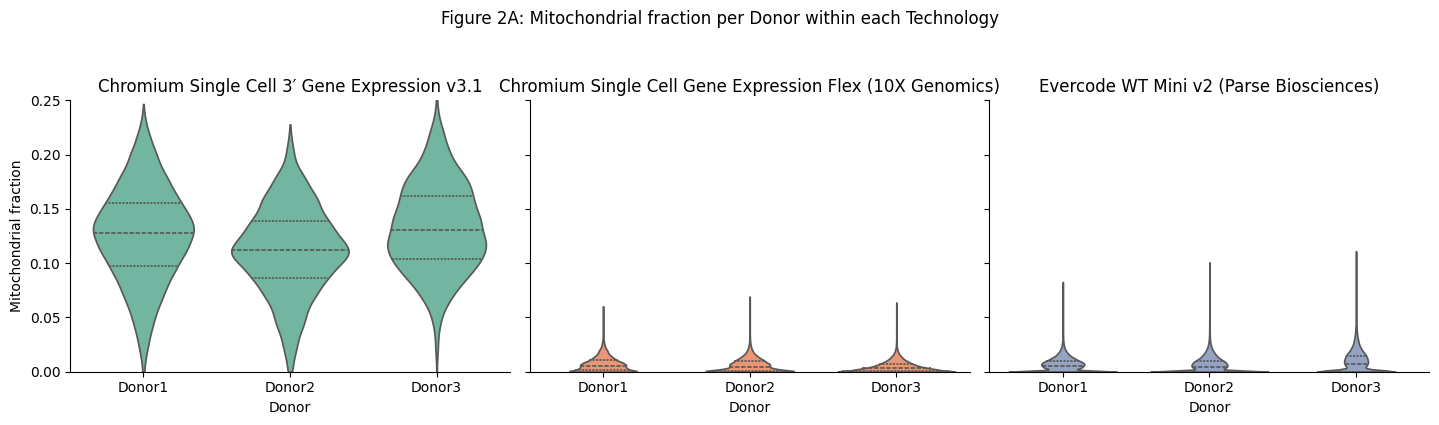

In [2]:
# =============================================================================
# 4. Common plotting utilities for Figures 2A–2C
# =============================================================================

# Map short technology codes to the full descriptive labels used in the paper
tech_map = {
    '10X3prime': 'Chromium Single Cell 3′ Gene Expression v3.1',
    '10Xfixed':  'Chromium Single Cell Gene Expression Flex (10X Genomics)',
    'Parse':     'Evercode WT Mini v2 (Parse Biosciences)',
    'HIVE':      'HIVE scRNAseq v1 (Honeycomb Biotechnologies)',
}

# Tidy DataFrame of QC metrics (subset: mito_fraction + total_counts)
df_qc = pd.DataFrame({
    "Donor":           rbc_cells.obs["Donor"].astype(str),
    "Technology_code": rbc_cells.obs["technology"].astype(str),
    "UMI counts":      rbc_cells.obs["total_counts"].values,
    "Mitochondrial fraction": rbc_cells.obs["mito_fraction"].values,
})

# Define the order of technologies and donors for consistent faceting
tech_order = [
    t for t in ["10X3prime", "10Xfixed", "Parse", "HIVE"]
    if t in df_qc["Technology_code"].unique()
]
donor_order = sorted(df_qc["Donor"].unique().tolist())

# Color palette: assign one color per technology
palette = sns.color_palette("Set2", n_colors=len(tech_order))
tech_color_map = {tech_order[i]: palette[i] for i in range(len(tech_order))}


# =============================================================================
# 5. Figure 2A — Mitochondrial fraction per Donor within each Technology
# =============================================================================
# Faceted violin plot:
#   • Columns: Technology_code
#   • X-axis: Donor
#   • Y-axis: mito_fraction
#   • Color: technology (redundant but keeps mapping consistent)
# =============================================================================

g = sns.catplot(
    data=df_qc,
    kind="violin",
    col="Technology_code",
    x="Donor",
    y="Mitochondrial fraction",
    order=donor_order,
    col_order=tech_order,
    hue="Technology_code",
    palette=tech_color_map,
    inner="quartile",
    cut=0,
    sharey=True,
    height=4,
    aspect=1.1,
)

# Match y-limits to range used in the paper
g.set(ylim=(0, 0.25))

# Replace panel titles with full technology names
for ax, tech in zip(g.axes.flatten(), tech_order):
    ax.set_title(tech_map.get(tech, tech))

g.set_xlabels("Donor")
g.set_ylabels("Mitochondrial fraction")

# Legend is redundant (each panel plots a single tech), so remove it
g._legend.remove()

plt.suptitle("Figure 2A: Mitochondrial fraction per Donor within each Technology", y=1.05)
plt.tight_layout()
plt.show()

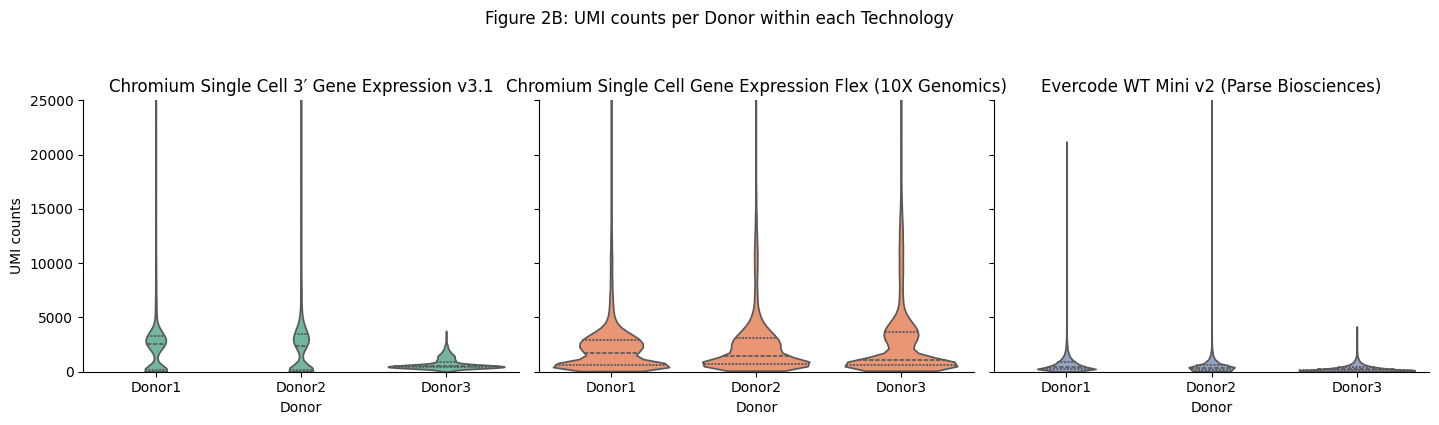

In [3]:
# =============================================================================
# 6. Figure 2B — UMI counts per Donor within each Technology
# =============================================================================
# Same structure as 2A but with total UMI counts on the y-axis.
# =============================================================================

g = sns.catplot(
    data=df_qc,
    kind="violin",
    col="Technology_code",
    x="Donor",
    y="UMI counts",
    order=donor_order,
    col_order=tech_order,
    hue="Technology_code",
    palette=tech_color_map,
    inner="quartile",
    cut=0,
    sharey=True,
    height=4,
    aspect=1.1,
)

g.set(ylim=(0, 25000))

for ax, tech in zip(g.axes.flatten(), tech_order):
    ax.set_title(tech_map.get(tech, tech))

g.set_xlabels("Donor")
g.set_ylabels("UMI counts")

g._legend.remove()

plt.suptitle("Figure 2B: UMI counts per Donor within each Technology", y=1.05)
plt.tight_layout()
plt.show()

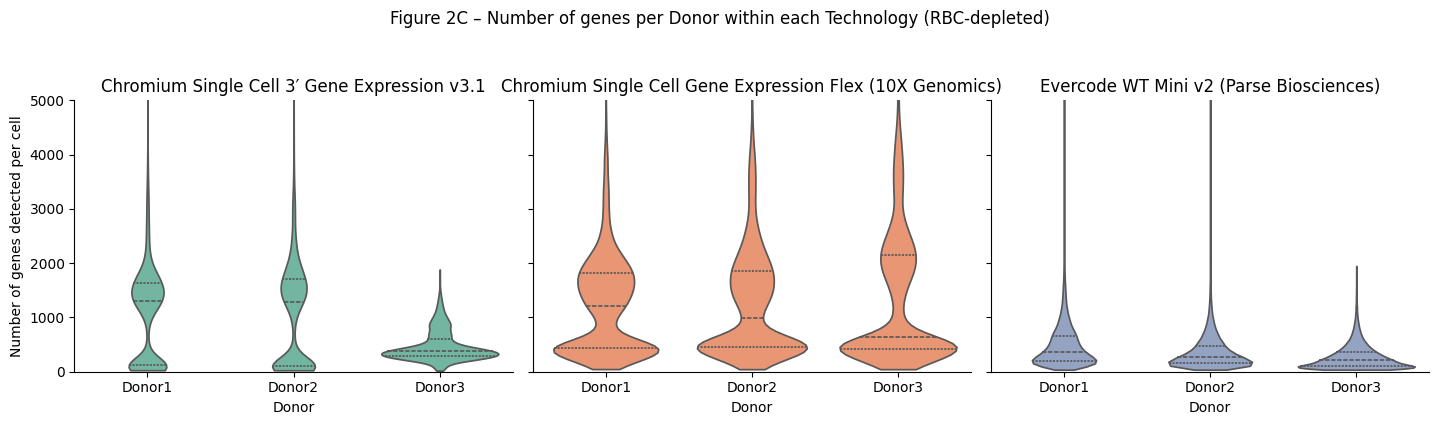

In [4]:
# =============================================================================
# 7. Figure 2C — Number of genes per Donor within each Technology
# =============================================================================
# Use n_genes_by_counts as the y-axis. Structure matches 2A/2B.
# =============================================================================

df_qc_genes = pd.DataFrame({
    "Donor":           rbc_cells.obs["Donor"].astype(str),
    "Technology_code": rbc_cells.obs["technology"].astype(str),
    "Number of genes": rbc_cells.obs["n_genes_by_counts"].astype(float),
})

# Recompute tech_order/donor_order in case of slight differences
tech_order = [
    t for t in ["10X3prime", "10Xfixed", "Parse", "HIVE"]
    if t in df_qc_genes["Technology_code"].unique()
]
donor_order = sorted(df_qc_genes["Donor"].unique().tolist())

# Keep color mapping consistent (one color per technology)
base_palette = sns.color_palette("Set2", n_colors=4)
tech_color_map_genes = {
    code: base_palette[i] for i, code in enumerate(["10X3prime", "10Xfixed", "Parse", "HIVE"])
    if code in tech_order
}

g = sns.catplot(
    data=df_qc_genes,
    kind="violin",
    col="Technology_code",        # one column per technology
    x="Donor",                    # donors on x-axis
    y="Number of genes",          # number of genes detected per cell
    order=donor_order,
    col_order=tech_order,
    hue="Technology_code",
    palette=tech_color_map_genes,
    inner="quartile",
    cut=0,
    sharey=True,
    height=4,
    aspect=1.1,
)

# Set y-range to roughly match typical single-cell gene counts
g.set(ylim=(0, 5000))

for ax, tech in zip(g.axes.flatten(), tech_order):
    ax.set_title(tech_map.get(tech, tech))

g.set_xlabels("Donor")
g.set_ylabels("Number of genes detected per cell")

if g._legend is not None:
    g._legend.remove()

plt.suptitle("Figure 2C – Number of genes per Donor within each Technology (RBC-depleted)", y=1.05)
plt.tight_layout()
plt.show()


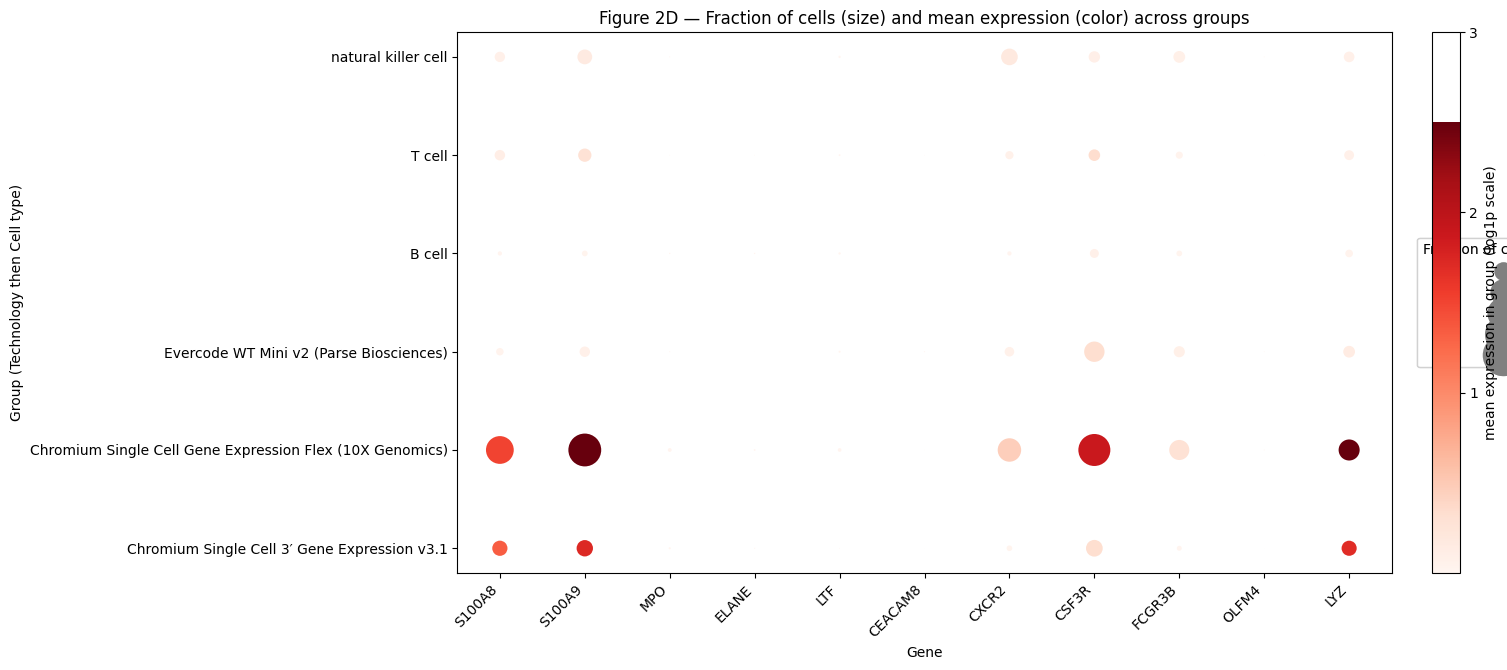

In [5]:
# =============================================================================
# 8. Figure 2D — Dot plot across Technologies and Cell Types
# =============================================================================
# Goal:
#   • Rows: all technologies (top), followed by selected immune cell types.
#   • Columns: selected neutrophil/immune marker genes.
#   • Dot size: fraction of cells in the group expressing the gene (>0 counts).
#   • Dot color: log1p(mean raw expression) in the group.
# =============================================================================

# --- 8.1 Configure gene list and cell-type column -----------------------------
genes_for_dotplot = [
    "S100A8", "S100A9", "MPO", "ELANE", "LTF", "CEACAM8", "CXCR2",
    "CSF3R", "FCGR3B", "OLFM4", "LYZ", "GAPDH"
]

# Keep only genes actually present in the dataset
present_genes = [g for g in genes_for_dotplot if g in rbc_cells.var_names]
if not present_genes:
    raise ValueError("None of the selected genes are present in rbc_cells.var_names.")

# Choose an existing cell-type annotation column
celltype_candidates = ["celltype1", "celltype0", "celltype2", "cell_type", "CellType"]
celltype_col = next((c for c in celltype_candidates if c in rbc_cells.obs.columns), None)
if celltype_col is None:
    raise KeyError("Could not find a cell-type column in rbc_cells.obs.")

# Cell types of interest (in desired row order, if present)
wanted_celltypes = ["B cell", "T cell", "monocyte", "natural killer cell", "neutrophil"]

# Technology codes and their preferred order
tech_codes = rbc_cells.obs["technology"].astype(str).unique().tolist()
tech_order = [t for t in ["10X3prime", "10Xfixed", "Parse", "HIVE"] if t in tech_codes]

# Helper to convert sparse/dense to a dense numpy array
def to_dense(m):
    return m.toarray() if issparse(m) else np.asarray(m)

# --- 8.2 Aggregate per group (technology and cell type) ----------------------
rows = []

# Per-technology groups (rows at the top)
for tech in tech_order:
    sub = rbc_cells[rbc_cells.obs["technology"].astype(str) == tech]
    X = to_dense(sub[:, present_genes].X)
    frac = (X > 0).mean(axis=0)         # fraction of cells expressing gene
    mean_expr = X.mean(axis=0)         # mean raw expression
    for g, f, m in zip(present_genes, frac, mean_expr):
        rows.append({
            "Group": tech,
            "GroupType": "Technology",
            "Gene": g,
            "Fraction": f,
            "MeanExpr": np.log1p(m),   # log1p transform for color scale
        })

# Per-cell-type groups (rows after technologies)
present_ct = [
    ct for ct in wanted_celltypes
    if ct in set(rbc_cells.obs[celltype_col].astype(str))
]
for ct in present_ct:
    sub = rbc_cells[rbc_cells.obs[celltype_col].astype(str) == ct]
    X = to_dense(sub[:, present_genes].X)
    frac = (X > 0).mean(axis=0)
    mean_expr = X.mean(axis=0)
    for g, f, m in zip(present_genes, frac, mean_expr):
        rows.append({
            "Group": ct,
            "GroupType": "CellType",
            "Gene": g,
            "Fraction": f,
            "MeanExpr": np.log1p(m),
        })

dot_df = pd.DataFrame(rows)

# --- 8.3 Define y-axis order and labels --------------------------------------
y_order = tech_order + present_ct   # technologies first, then cell types

def pretty_group_label(x):
    """Map technology codes to full names; leave cell-type names unchanged."""
    return tech_map.get(x, x)

dot_df["Group"] = pd.Categorical(dot_df["Group"], categories=y_order, ordered=True)
dot_df["Gene"] = pd.Categorical(dot_df["Gene"], categories=present_genes, ordered=True)

# --- 8.4 Build scatter coordinates and aesthetics ----------------------------
fig_h = 0.8 * len(y_order) + 2   # dynamic height based on number of rows
fig_w = 1.1 * len(present_genes) + 3
fig, ax = plt.subplots(figsize=(fig_w, fig_h))

x_pos = {g: i for i, g in enumerate(present_genes)}
y_pos = {grp: i for i, grp in enumerate(y_order)}

xs = dot_df["Gene"].map(x_pos).values
ys = dot_df["Group"].map(y_pos).values

# Dot size ∝ fraction of expressing cells (%), scaled for readability
sizes_percent = dot_df["Fraction"].values * 100.0
size_scale = 9.0
sizes_pts = sizes_percent * size_scale

# Dot color = log1p(mean expression)
colors = dot_df["MeanExpr"].values
scat = ax.scatter(xs, ys, s=sizes_pts, c=colors, cmap="Reds", edgecolor="none")

# Axes labels/ticks
ax.set_xticks(range(len(present_genes)))
ax.set_xticklabels(present_genes, rotation=45, ha="right")

ax.set_yticks(range(len(y_order)))
ax.set_yticklabels([pretty_group_label(y) for y in y_order])

ax.set_xlabel("Gene")
ax.set_ylabel("Group (Technology then Cell type)")
ax.set_title("Figure 2D — Fraction of cells (size) and mean expression (color) across groups")

# --- 8.5 Legends: dot size = fraction, colorbar = mean expression -----------
# Size legend for fractions 20/40/60/80/100%
legend_percents = [20, 40, 60, 80, 100]
legend_sizes = [p * size_scale for p in legend_percents]
handles = [plt.scatter([], [], s=s, color="gray", edgecolor="none") for s in legend_sizes]
labels = [f"{p}" for p in legend_percents]

size_legend = ax.legend(
    handles,
    labels,
    title="Fraction of cells in group (%)",
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    frameon=True,
)
ax.add_artist(size_legend)

# Colorbar for log1p(mean expression)
cbar = fig.colorbar(scat, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("mean expression in group (log1p scale)")
cbar.set_ticks([1, 2, 3])
cbar.set_ticklabels(["1", "2", "3"])

plt.tight_layout()
plt.show()

# Notes:
# • If a technology or cell type is missing from y_order, it simply had no cells
#   in the RBC-depleted subset (or that label is not present in the data).
# • Adjust size_scale if dots look too small/large in your exported figure.
